In [108]:
import pandas as pd
import numpy as np
import seaborn as sea
import matplotlib.pyplot as plt
%matplotlib inline

In [109]:
from kagglehub.datasets import dataset_download
import kagglehub
from google.colab import userdata

KAGGLE_API_KEY = userdata.get('KAGGLE_API_KEY')

#Downloading using kagglehub.dataset_download
dataset_handle = "yash9439/ipl-dataset"
path = kagglehub.dataset_download(dataset_handle)

print(f"Path to dataset files: {path}")


Using Colab cache for faster access to the 'ipl-dataset' dataset.
Path to dataset files: /kaggle/input/ipl-dataset


#1. First dataset cleaning

In [110]:
# import_dataset
dataset = pd.read_csv(f"/root/.cache/kagglehub/datasets/yash9439/ipl-dataset/versions/1/deliveries.csv")

In [111]:
#5_records_of_the_dataset_deliveries
dataset.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [112]:
#Rows_columns_and_datatypes_in_dataset_using_pd.info()
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 non-null  int

In [113]:
#Let_us_know_how_many_NaN_features_we_have
display(dataset.isnull().sum())

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
is_super_over,0


we_need_to_address_these_three_features
player_dismissed	143022
dismissal_kind	143022
fielder	145091

In [114]:
#Let_us_use_pd.describe_function
display(dataset.describe())

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000
mean,318.281317,1.482188,10.142649,3.616483,0.000538,0.037498,0.004885,0.022232,0.004340,0.000066,1.222445,0.069022,1.291466
std,182.955531,0.501768,5.674338,1.807698,0.023196,0.257398,0.114234,0.200104,0.072652,0.018229,1.594509,0.349667,1.583240
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,161.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,319.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,476.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,636.000000,4.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,6.000000,7.000000,7.000000


In [115]:
#Top10_bowler_that_gave_least_run
#Top10_bowler_that_gave_most_run
#Top_10_batsmen_who_scored_most_run
#Top_10_who_scored_least
#Most_wide_bowler
# most_no_balls_player
#Most_wide_ball_player_
#Most_dismissals
#All_matchups

In [116]:
delivery_dataset = dataset.copy()

In [117]:
numerical_columns = [feature for feature in delivery_dataset.columns if dataset[feature].dtype != 'object' and feature not in ['match_id','inning']]
display(numerical_columns)

['over',
 'ball',
 'is_super_over',
 'wide_runs',
 'bye_runs',
 'legbye_runs',
 'noball_runs',
 'penalty_runs',
 'batsman_runs',
 'extra_runs',
 'total_runs']

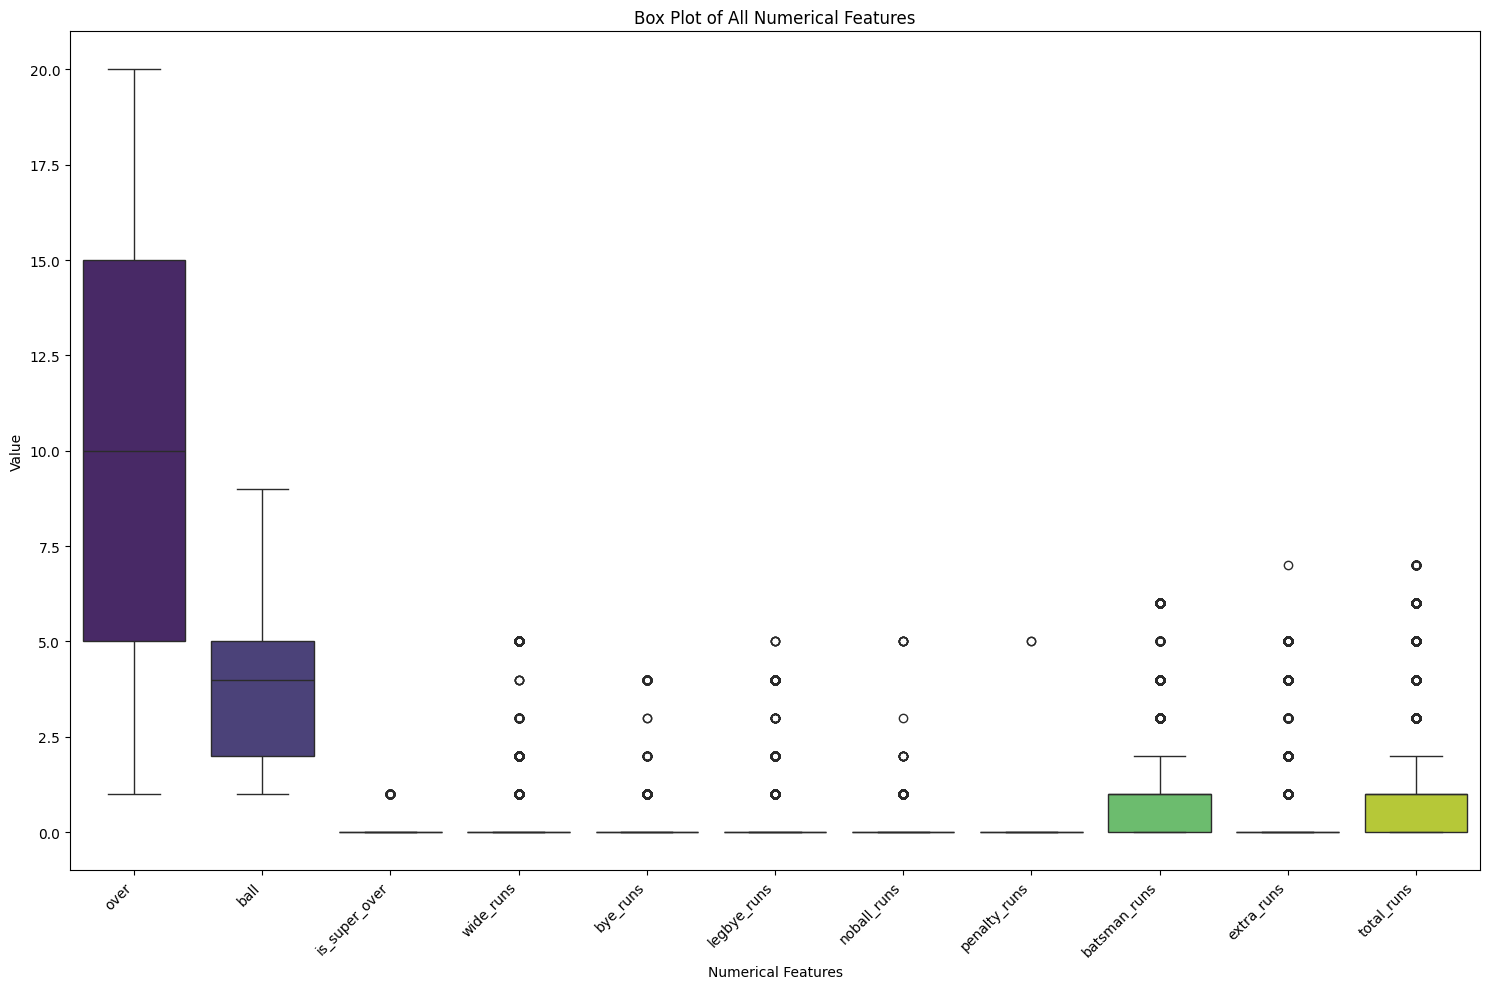

In [118]:
#Using dataset.melts fro visualising multiple numerical columns using box plot.
melted_data_before_capping = delivery_dataset.melt(
                    value_vars= numerical_columns,var_name='Numerical Feature',
                    value_name='Value')

#Create a sigle figure with subplots for each box plot.
plt.figure(figsize=(15,10))
sea.boxplot(x='Numerical Feature',y='Value', hue='Numerical Feature',
            data=melted_data_before_capping,palette='viridis', legend=False)
plt.title("Box Plot of All Numerical Features")
plt.xlabel('Numerical Features')
plt.ylabel("Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

"i" decided to keep the dataset with outliers because you found that the capping process "ruined the data." In the context of cricket, what might appear as a statistical outlier can often be a meaningful and crucial data point, and you preferred to retain the original distribution and its contextual significance.

In [119]:
# player_dismissed	143022
# dismissal_kind	143022
# fielder	145091

delivery_dataset['player_dismissed']= delivery_dataset['player_dismissed'].fillna("not out")

delivery_dataset['dismissal_kind'] = delivery_dataset['dismissal_kind'].fillna("N/A")

delivery_dataset['fielder'] = delivery_dataset['fielder'].fillna("N/A")


In [120]:
delivery_dataset.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
is_super_over,0


In [121]:
print(f"Number of duplicate rows: {delivery_dataset.duplicated().sum()}")

Number of duplicate rows: 1


In [122]:
delivery_dataset.drop_duplicates(inplace=True)

In [123]:
print(f"Number of duplicate rows after dropping: {delivery_dataset.duplicated().sum()}")

Number of duplicate rows after dropping: 0


#2. Second dataset cleaning.

In [124]:
dataset = pd.read_csv("/root/.cache/kagglehub/datasets/yash9439/ipl-dataset/versions/1/matches.csv")

In [125]:
dataset.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [126]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [127]:
dataset.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,0.025132,13.283069,3.350529
std,3464.478148,3.366895,0.156630,23.471144,3.387963
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,1.000000,146.000000,10.000000


In [128]:
dataset.isnull().sum()

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [129]:
null_winner_rows = dataset[dataset['winner'].isnull()]
display(null_winner_rows)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
300,301,2011,Delhi,2011-05-21,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,0,NaN,0,0,NaN,Feroz Shah Kotla,SS Hazare,RJ Tucker,NaN
545,546,2015,Bangalore,2015-04-29,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,JD Cloete,PG Pathak,NaN
570,571,2015,Bangalore,2015-05-17,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,HDPK Dharmasena,K Srinivasan,NaN
744,11340,2019,Bengaluru,30/04/19,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M. Chinnaswamy Stadium,Nigel Llong,Ulhas Gandhe,Anil Chaudhary


In [130]:
display(dataset[dataset['umpire1'].isnull()])

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
753,11413,2019,Visakhapatnam,08/05/19,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN


In [131]:
display(dataset[dataset['umpire2'].isnull()])

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
753,11413,2019,Visakhapatnam,08/05/19,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN


In [132]:
display(dataset[dataset['city'].isnull()])

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
461,462,2014,NaN,2014-04-19,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,7,PA Patel,Dubai International Cricket Stadium,Aleem Dar,AK Chaudhary,NaN
462,463,2014,NaN,2014-04-19,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,normal,0,Delhi Daredevils,0,4,JP Duminy,Dubai International Cricket Stadium,Aleem Dar,VA Kulkarni,NaN
466,467,2014,NaN,2014-04-23,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,normal,0,Chennai Super Kings,7,0,RA Jadeja,Dubai International Cricket Stadium,HDPK Dharmasena,RK Illingworth,NaN
468,469,2014,NaN,2014-04-25,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,normal,0,Sunrisers Hyderabad,4,0,AJ Finch,Dubai International Cricket Stadium,M Erasmus,S Ravi,NaN
469,470,2014,NaN,2014-04-25,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Chennai Super Kings,0,7,MM Sharma,Dubai International Cricket Stadium,BF Bowden,M Erasmus,NaN
474,475,2014,NaN,2014-04-28,Royal Challengers Bangalore,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,5,Sandeep Sharma,Dubai International Cricket Stadium,BF Bowden,S Ravi,NaN
476,477,2014,NaN,2014-04-30,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Sunrisers Hyderabad,15,0,B Kumar,Dubai International Cricket Stadium,HDPK Dharmasena,M Erasmus,NaN


In [133]:
dataset['season'].value_counts()

,count
season,
2013,76
2012,74
2011,73
2010,60
2016,60
2018,60
2019,60
2014,60
2017,59


In [134]:
dataset['dl_applied'].value_counts()

,count
dl_applied,
0,737
1,19


In [135]:
match_dataset= dataset.copy()

In [136]:
match_dataset['umpire3']=match_dataset['umpire3'].fillna('umpire3')

In [137]:
umpire1_mode = match_dataset['umpire1'].mode()[0]
umpire2_mode = match_dataset['umpire2'].mode()[0]

match_dataset['umpire1'] = match_dataset['umpire1'].fillna(umpire1_mode)
match_dataset['umpire2'] = match_dataset['umpire2'].fillna(umpire2_mode)

In [138]:
match_dataset['winner'] = match_dataset['winner'].fillna("Tie")
match_dataset['player_of_match'] =match_dataset['player_of_match'].fillna("No Winner")

In [139]:
match_dataset.isnull().sum()

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [140]:
# Get venues where city is null
venues_with_null_city = match_dataset[match_dataset['city'].isnull()]['venue'].unique()
print(f"Venues with null cities: {venues_with_null_city}")

Venues with null cities: ['Dubai International Cricket Stadium']


In [141]:
# Create a mapping from venue to city using non-null entries
venue_to_city_mapping = match_dataset.dropna(subset=['city']).groupby('venue')['city'].agg(lambda x: x.mode()[0]).to_dict()


Now, let's confirm if all the 'city' null values have been filled.

In [142]:
print(f"Number of null values in 'city' after filling: {match_dataset['city'].isnull().sum()}")

Number of null values in 'city' after filling: 7


In [143]:
match_dataset.loc[match_dataset['venue'] == 'Dubai International Cricket Stadium', 'city'] = 'Dubai'

In [144]:
match_dataset.isnull().sum()

,0
id,0
season,0
city,0
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [145]:
match_dataset.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [146]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [ ]:
# top_winners
# top_losers
# toss_winners
# most_winners_by_wicketandruns
# top_player_of_the_match
# most_played_city
# city_and_team1(hometeam)relation
# city_and_team2_relation
# toss_winnerv/s_game_winner
# season_wise_srting_and_analysis.
# win_percent
# performance_trend_per_season
# dl_applied_wicket_and_run_groupby
#

In [147]:
numerical_columns = [feature for feature in dataset.columns if dataset[feature].dtype != 'object' and feature not in ['id']]

display(numerical_columns)

['season', 'dl_applied', 'win_by_runs', 'win_by_wickets']

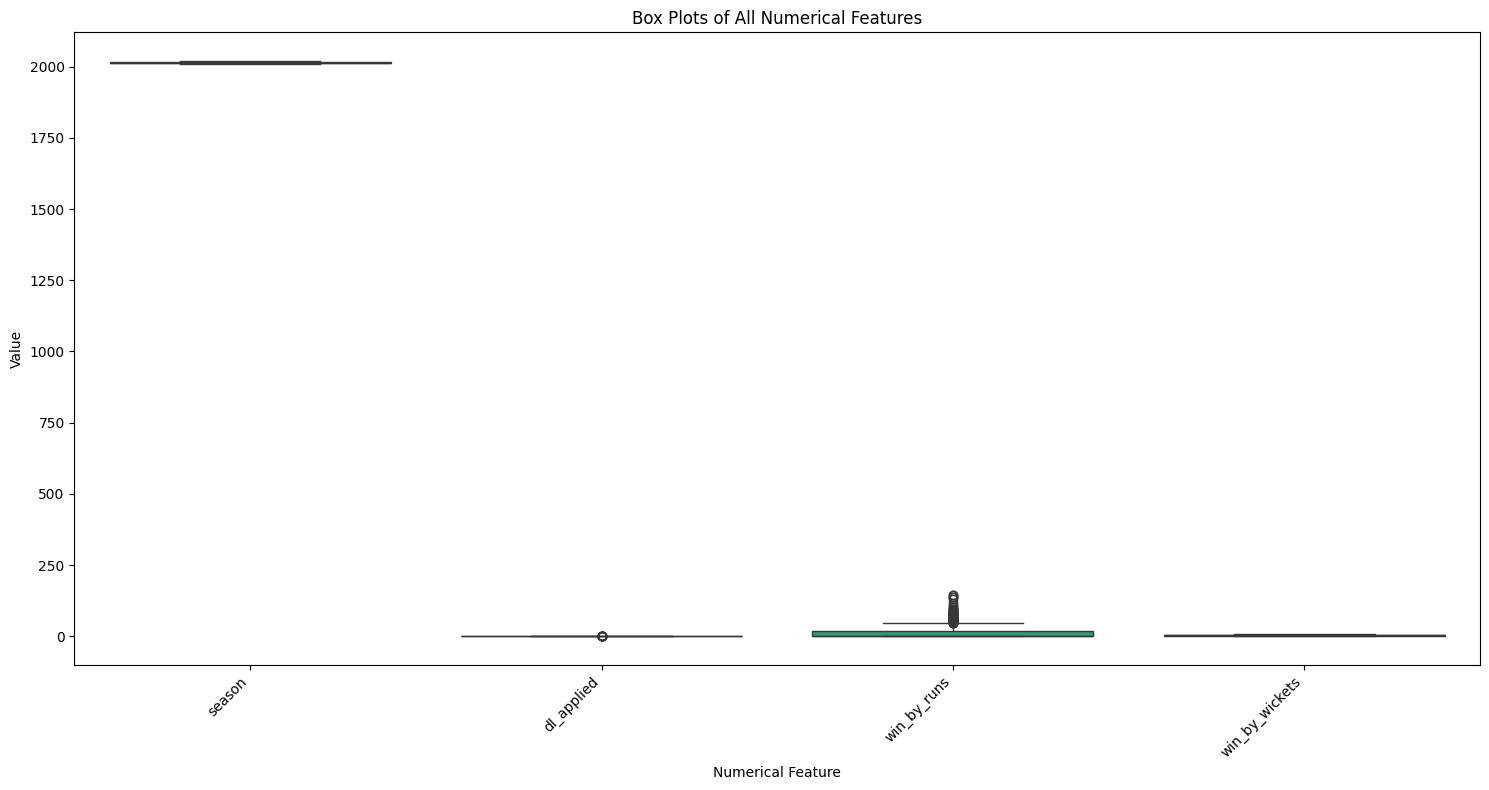

In [148]:
#Vectorised boxplotfor numerical features

melted_data_before_capping = match_dataset.melt(value_vars=numerical_columns,
                                                var_name='Numerical Feature',
                                                value_name="Value")

plt.figure(figsize=(15,8))
sea.boxplot(x='Numerical Feature', y='Value', hue='Numerical Feature',data=melted_data_before_capping,palette='viridis',legend=False)
plt.title("Box Plots of All Numerical Features")
plt.xlabel('Numerical Feature')
plt.ylabel('Value')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()










In [150]:
dataset['team1'].value_counts()

,count
team1,
Mumbai Indians,101
Kings XI Punjab,91
Chennai Super Kings,89
Royal Challengers Bangalore,85
Kolkata Knight Riders,83
Delhi Daredevils,72
Rajasthan Royals,67
Sunrisers Hyderabad,63
Deccan Chargers,43


### Standardizing Team Names

Based on the `value_counts()` output, we need to address a few team name inconsistencies for better analysis:

*   `Rising Pune Supergiant` and `Rising Pune Supergiants` are the same team.
*   `Delhi Daredevils` changed to `Delhi Capitals`.
*   `Deccan Chargers` was a predecessor to `Sunrisers Hyderabad`.

Let's create a mapping and apply these changes to the `match_dataset`.

In [153]:
team_name_mapp = {
                  'Rising Pune Supergiats' : 'Rising Pune Supergiant',
                  'Delhi Daredevils':'Delhi Capitals',
                  'Deccan Chargers':'Sunrisers Hyderabad'
}

def standardize_team_names(df,columns):
  for col in columns:
    df[col] = df[col].replace(team_name_mapp)
  return df

team_columns =['team1','team2','toss_winner','winner']
match_dataset= standardize_team_names(match_dataset.copy(),team_columns)

Now, let's check the value counts for `team1` again to confirm the changes.

In [154]:
match_dataset['team1'].value_counts()

,count
team1,
Sunrisers Hyderabad,106
Mumbai Indians,101
Kings XI Punjab,91
Chennai Super Kings,89
Royal Challengers Bangalore,85
Kolkata Knight Riders,83
Delhi Capitals,78
Rajasthan Royals,67
Pune Warriors,20
